[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5929/2343645736.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_column = df.select_dtypes(include="object").columns[0]


Dataset shape: (817, 7)
Columns: ['Category', 'Source', 'Question', 'Examples: True', 'Examples: False', 'Examples: Informative', 'Examples: Uninformative']
TF-IDF shape: (817, 52)
Best K: 10
Silhouette Score: 0.5258779159594982

Cluster sizes:
cluster
0    353
1     55
2    100
3     26
4     64
5     46
6     55
7     30
8     31
9     57
Name: count, dtype: int64

Cluster 0:
conspiracy, stereotype, history, superstition, language, psychology, proverb, weather, nutrition, misquotation

Cluster 1:
sociology, weather, error time, language, indexical error, indexical, identity, history, health, finance

Cluster 2:
misconception, weather, location, language, indexical error, indexical, identity, history, health, finance

Cluster 3:
paranormal, weather, location, language, indexical error, indexical, identity, history, health, finance

Cluster 4:
law, weather, topical, language, indexical error, indexical, identity, history, health, finance

Cluster 5:
confusion, confusion people, people,

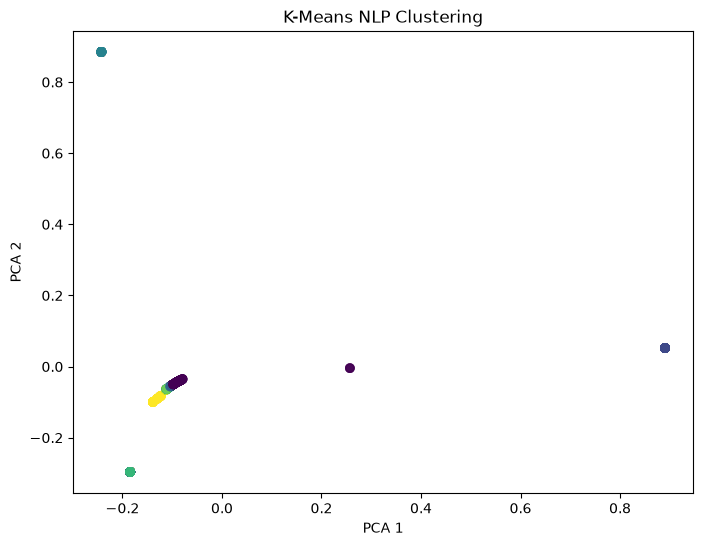


Saved as: eval_examples_clustered.csv


In [1]:
# =========================================================
# NLP + K-MEANS CLUSTERING - eval_examples.csv
# =========================================================

# Install if required:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Download NLP resources
nltk.download("stopwords")
nltk.download("wordnet")

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------

df = pd.read_csv("eval_examples.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Change this to your actual text column
text_column = df.select_dtypes(include="object").columns[0]

df = df.dropna(subset=[text_column]).copy()

# ---------------------------------------------------------
# 2. NLP PREPROCESSING
# ---------------------------------------------------------

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words and len(w) > 2
    ]
    
    return " ".join(words)

df["clean_text"] = df[text_column].astype(str).apply(clean_text)

# ---------------------------------------------------------
# 3. TF-IDF
# ---------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)

# ---------------------------------------------------------
# 4. FIND BEST K
# ---------------------------------------------------------

scores = {}

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)

print("Best K:", best_k)
print("Silhouette Score:", scores[best_k])

# ---------------------------------------------------------
# 5. FINAL K-MEANS
# ---------------------------------------------------------

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

# ---------------------------------------------------------
# 6. SHOW CLUSTERS
# ---------------------------------------------------------

print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

# Top words in each cluster
terms = vectorizer.get_feature_names_out()

for i in range(best_k):
    center = kmeans.cluster_centers_[i]
    top_words = center.argsort()[-10:][::-1]
    
    print(f"\nCluster {i}:")
    print(", ".join(terms[j] for j in top_words))

# ---------------------------------------------------------
# 7. VISUALISE
# ---------------------------------------------------------

pca = PCA(n_components=2, random_state=42)
X_2D = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(
    X_2D[:, 0],
    X_2D[:, 1],
    c=df["cluster"],
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means NLP Clustering")
plt.show()

# ---------------------------------------------------------
# 8. SAVE RESULTS
# ---------------------------------------------------------

df.to_csv(
    "eval_examples_clustered.csv",
    index=False
)

print("\nSaved as: eval_examples_clustered.csv")